In [194]:
from mesa import Agent, Model
from mesa.space import MultiGrid
from mesa.time import SimultaneousActivation
from mesa.datacollection import DataCollector
import math
import numpy as np

class Consument(Agent):
    """Een inwoner van Rotterdam met individueel recyclinggedrag."""

    INIT_RECYCLING_PERCENTAGE = 0.5
    GEWICHT_PER_STUK = 0.24          # gemiddeld gewicht kledingstuk in kg
    TEXTIEL_PER_JAAR_KG = 12.1       # totaal afgedankt textiel per persoon per jaar in kg
    AFGEDANKT_PER_JAAR = TEXTIEL_PER_JAAR_KG / GEWICHT_PER_STUK
    AFGEDANKT_PER_MAAND = AFGEDANKT_PER_JAAR / 12

    BELOONING_GROEISNELHEID = 0.8
    BELOONING_MIDDEN = 3.0

    MAX_EFFECT_GEMAK = 0.4
    MAX_TOTAAL_GEMAK_EFFECT = 0.3
    
    BIAS_CORRECTIE = 0.0  # kalibratie voor als dat nodig is

    def advance(self):
        # Voor nu niks extra’s, maar verplicht voor SimultaneousActivation
        pass
    
    def __init__(self, unique_id, model, locatie):
        super().__init__(unique_id, model)
        self.locatie = locatie

        # Individuele eigenschappen
        self.milieubewustzijn = self.random.uniform(0, 1)
        self.prijsgevoeligheid = self.random.uniform(0, 1)
        self.gemaksgevoeligheid = self.random.uniform(0, 1)
        self.sociale_druk_gevoeligheid = self.random.uniform(0, 1)

        # Gedragstoestand
        self.sociale_druk = 0.5
        self.aantal_gerecycled = 0
        self.aantal_weggegooid = 0
        # alleen laatste maand
        self.gerecycled_deze_maand = 0
        self.weggegooid_deze_maand = 0
        self.bekend_met_beloning = 1 if self.random.random() < 0.05 else 0

        self.afgedankt_textiel = self.AFGEDANKT_PER_MAAND
        self.afstand_inzamelpunt = None
        self.afstand_inzamelpunt_basis = None
        self.waargenomen_afstand_inzamelpunt = None


    def update_bekendheid_beloning(self):
        """Laat bekendheid met de beloning zich verspreiden via buren."""
        if self.bekend_met_beloning == 1:
            return

        neighbors = self.model.grid.get_neighbors(
            self.pos, moore=True, include_center=False, radius=2
        )

        if not neighbors:
            return

        aandeel_bekend = sum(n.bekend_met_beloning for n in neighbors) / len(neighbors)

        kans_op_bekend_worden = 0.02 + 0.25 * aandeel_bekend

        if self.random.random() < kans_op_bekend_worden:
            self.bekend_met_beloning = 1

    def update_waargenomen_afstand(self):
        """Laat de ervaren afstand geleidelijk verschuiven naar de echte afstand."""
        if self.waargenomen_afstand_inzamelpunt is None or self.afstand_inzamelpunt is None:
            return

        leersnelheid = 0.25
        self.waargenomen_afstand_inzamelpunt = (
            self.waargenomen_afstand_inzamelpunt
            + leersnelheid * (self.afstand_inzamelpunt - self.waargenomen_afstand_inzamelpunt)
        )
    
    
    def bepaal_recycling_kans(self):
        """Berekent de kans dat deze agent recycleert op basis van beleid en persoonlijke factoren."""
        basis = self.INIT_RECYCLING_PERCENTAGE
        beloning = self.model.beloning_per_stuk

        # Beloningseffect (aangepast zodat €0 → geen effect)
        if beloning <= 0:
            # Geen beloning → geen effect
            reward_effect = 0
        else:
            # Logistische respons op de hoogte van de beloning
            beloning_factor = 1 / (1 + math.exp(
                -self.BELOONING_GROEISNELHEID * (beloning - self.BELOONING_MIDDEN)
            ))

            # Baseline bij €0 berekenen en weghalen
            baseline = 1 / (1 + math.exp(
                -self.BELOONING_GROEISNELHEID * (0 - self.BELOONING_MIDDEN)
            ))

            # Nu is beloning_factor = 0 bij €0
            beloning_factor -= baseline

            reward_effect = self.bekend_met_beloning * self.prijsgevoeligheid * 0.4 * max(0, beloning_factor)
        
        # Gemakseffect: logistische (S‑vormige) respons op afstand
        #if self.afstand_inzamelpunt is not None and self.afstand_inzamelpunt_basis is not None:
            # Logistische scores voor huidige en basisafstand
            # -> dichterbij (kleinere afstand) geeft hogere score (tussen 0 en 1)
            #gemak_score = 1 / (1 + math.exp(0.25 * (self.afstand_inzamelpunt - 12)))
            #basis_gemak_score = 1 / (1 + math.exp(0.25 * (self.afstand_inzamelpunt_basis - 12)))

        if self.waargenomen_afstand_inzamelpunt is not None and self.afstand_inzamelpunt_basis is not None:
            gemak_score = 1 / (1 + math.exp(0.25 * (self.waargenomen_afstand_inzamelpunt - 12)))
            basis_gemak_score = 1 / (1 + math.exp(0.25 * (self.afstand_inzamelpunt_basis - 12)))
        
            # Verschil in gemak (huidig versus basis)
            delta_gemak = gemak_score - basis_gemak_score

            # Effect verzwaren met gevoeligheid en maximale schaal
            gemak_effect = self.gemaksgevoeligheid * self.MAX_EFFECT_GEMAK * delta_gemak
        else:
            gemak_effect = 0

        # Inperken binnen gewenste grenzen
        gemak_effect_adjusted = max(
            -self.MAX_TOTAAL_GEMAK_EFFECT,
            min(self.MAX_TOTAAL_GEMAK_EFFECT, gemak_effect)
        )

        # Sociale invloed (nabijgelegen buren)
        sociaal_effect = 0 #0.15 * self.sociale_druk_gevoeligheid * (self.sociale_druk - 0.5)

        # milieubewustzijn tussen 0 en 1:
        # onder 0.5 verlaagt recyclingkans, boven 0.5 verhoogt die kans
        milieu_effect = 0.2 * (self.milieubewustzijn - 0.5)

        # Totaaleffecten
        totale_effecten = reward_effect + gemak_effect_adjusted + sociaal_effect + milieu_effect
        return min(1, max(0, basis + totale_effecten - self.BIAS_CORRECTIE))

    def step(self):
        # Neem het gehele aantal stukken zeker mee, en het decimale deel als kans op 1 extra stuk
        """Voert één gedragscyclus uit (één simulatiemaand)."""
        p_recycle = self.bepaal_recycling_kans()
        gerecycled, weggegooid = 0, 0

        hele_stukken = int(self.afgedankt_textiel)
        rest_kans = self.afgedankt_textiel - hele_stukken

        aantal_stukken = hele_stukken
        if self.random.random() < rest_kans:
            aantal_stukken += 1

        for _ in range(aantal_stukken):
            if self.random.random() < p_recycle:
                gerecycled += 1
            else:
                weggegooid += 1
        
        # gedrag van deze maand opslaan
        self.gerecycled_deze_maand = gerecycled
        self.weggegooid_deze_maand = weggegooid

        self.aantal_gerecycled += gerecycled
        self.aantal_weggegooid += weggegooid

class RotterdamModel(Model):
    """Mesa‑model van textielinzameling in Rotterdam (base case)."""

    def __init__(self, grid_size=100, aantal_inzamelpunten=4, maanden=12, seed=None, vaste_inzamelpunten=None, beloning_per_stuk=0):
        super().__init__(seed=seed)
        self.grid = MultiGrid(grid_size, grid_size, torus=False)
        self.schedule = SimultaneousActivation(self)
        self.running = True
        self.maanden = maanden
        self.huidige_maand = 0
        self.beloning_per_stuk = beloning_per_stuk

        # Vaste inzamelpunten genereren voor eerlijke vergelijking
        if vaste_inzamelpunten is None:
            vaste_inzamelpunten = self.genereer_inzamelpunten(8, grid_size)

        self.base_inzamelpunten = vaste_inzamelpunten[:4]
        self.inzamelpunten = vaste_inzamelpunten[:aantal_inzamelpunten]

        # Agenten aanmaken
        agent_id = 0
        for x in range(grid_size):
            for y in range(grid_size):
                agent = Consument(agent_id, self, (x, y))
                self.schedule.add(agent)
                self.grid.place_agent(agent, (x, y))
                agent.afstand_inzamelpunt = self.afstand_tot_dichtstbijzijnde_inzamelpunt((x, y), self.inzamelpunten)
                agent.afstand_inzamelpunt_basis = self.afstand_tot_dichtstbijzijnde_inzamelpunt((x, y), self.base_inzamelpunten)
                agent.waargenomen_afstand_inzamelpunt = agent.afstand_inzamelpunt_basis
                agent_id += 1

        # DataCollector (+ /0‑check)

        self.datacollector = DataCollector(
            model_reporters={
                # cumulatief
                "TotaalGerecycled": lambda m: sum(a.aantal_gerecycled for a in m.schedule.agents),
                "TotaalWeggegooid": lambda m: sum(a.aantal_weggegooid for a in m.schedule.agents),
                "RecyclingPercentage": lambda m: (
                    0 if sum(a.aantal_gerecycled + a.aantal_weggegooid for a in m.schedule.agents) == 0
                    else sum(a.aantal_gerecycled for a in m.schedule.agents)
                    / sum(a.aantal_gerecycled + a.aantal_weggegooid for a in m.schedule.agents)
                ),
                # per maand
                "GerecycledDezeMaand": lambda m: sum(a.gerecycled_deze_maand for a in m.schedule.agents),
                "WeggegooidDezeMaand": lambda m: sum(a.weggegooid_deze_maand for a in m.schedule.agents),
                "RecyclingPercentageDezeMaand": lambda m: (
                    0 if sum(a.gerecycled_deze_maand + a.weggegooid_deze_maand for a in m.schedule.agents) == 0
                    else sum(a.gerecycled_deze_maand for a in m.schedule.agents)
                    / sum(a.gerecycled_deze_maand + a.weggegooid_deze_maand for a in m.schedule.agents)
                ),
                #Dit hier onder is nodig voor de plot milieubewustzijn of niet
                "TextielBewust": lambda m: sum(
                    a.gerecycled_deze_maand for a in m.schedule.agents if a.milieubewustzijn > 0.5
                ),
                "TextielOnbewust": lambda m: sum(
                    a.gerecycled_deze_maand for a in m.schedule.agents if a.milieubewustzijn <= 0.5
                ),
                "GemiddeldeAfstand": lambda m: np.mean([a.afstand_inzamelpunt for a in m.schedule.agents])
            }
        )
        self.datacollector.collect(self)

    # Gedrags- en interactiefuncties
    def afstand(self, p1, p2):
            """Bereken Euclidische afstand tussen twee punten."""
            return math.hypot(p1[0] - p2[0], p1[1] - p2[1])

    def afstand_tot_dichtstbijzijnde_inzamelpunt(self, agent_loc, punten):
        """Bereken de kortste afstand van een agent tot een inzamelpunt."""
        return min(self.afstand(agent_loc, p) for p in punten)

    def buren_recycling_ratio(self, agent):
        """Bereken het recyclingaandeel van de buren in deze maand."""
        neighbors = self.grid.get_neighbors(agent.pos, moore=True, include_center=False, radius=2)
        if not neighbors:
            return 0.5

        totaal_gerecycled = sum(n.gerecycled_deze_maand for n in neighbors)
        totaal_textiel = sum(
            n.gerecycled_deze_maand + n.weggegooid_deze_maand
            for n in neighbors
        )

        if totaal_textiel == 0:
            return 0.5

        return totaal_gerecycled / totaal_textiel

    def genereer_inzamelpunten(self, aantal, grid_size):
        """Genereer inzamelpunten met minimale afstand tussen elkaar."""
        locaties = []
        min_afstand = grid_size / 5  # bijvoorbeeld: 100 grid → 20 afstand

        while len(locaties) < aantal:
            nieuw_punt = (
                self.random.randint(0, grid_size - 1),
                self.random.randint(0, grid_size - 1)
            )

            #check afstand tot bestaande punten
            te_dichtbij = False
            for bestaand in locaties:
                if self.afstand(nieuw_punt, bestaand) < min_afstand:
                    te_dichtbij = True
                    break

            if not te_dichtbij:
                locaties.append(nieuw_punt)

        return locaties

    # Simulatiestap
    
    def step(self):
        self.huidige_maand += 1
        
        for agent in self.schedule.agents:
            agent.sociale_druk = self.buren_recycling_ratio(agent)

        for agent in self.schedule.agents:
            agent.update_bekendheid_beloning()

        for agent in self.schedule.agents:
            agent.update_waargenomen_afstand()

        self.schedule.step()
        self.datacollector.collect(self)

#   SIMULATIE DRAAIEN & RESULTATEN

# ENKELE RUN (debug / controle)
model = RotterdamModel(grid_size=100, aantal_inzamelpunten=4, maanden=12)

for maand in range(model.maanden):
    model.step()

data = model.datacollector.get_model_vars_dataframe()
maanden_labels = [
    "Jan", "Feb", "Mrt", "Apr", "Mei", "Jun",
    "Jul", "Aug", "Sep", "Okt", "Nov", "Dec", "Eind"
]

data = data.iloc[1:]  # eerste rij weg
data.index = maanden_labels[:len(data)]
print(data)
#print(data.tail())


     TotaalGerecycled  TotaalWeggegooid  RecyclingPercentage  \
Jan             21124             20863             0.503108   
Feb             42366             41696             0.503985   
Mrt             63638             62436             0.504767   
Apr             85128             83011             0.506295   
Mei            106686            103495             0.507591   
Jun            128445            123719             0.509371   
Jul            150504            143686             0.511588   
Aug            172733            163423             0.513848   
Sep            194879            183314             0.515290   
Okt            216938            203256             0.516281   
Nov            239217            222965             0.517582   
Dec            261375            242853             0.518367   

     GerecycledDezeMaand  WeggegooidDezeMaand  RecyclingPercentageDezeMaand  \
Jan                21124                20863                      0.503108   
Feb      

In [196]:
import pandas as pd
import matplotlib.pyplot as plt

def run_multiple_simulations_for_bins(aantal_inzamelpunten, vaste_inzamelpunten, n_runs=5, maanden=12, grid_size=100, beloning=0):
    alle_resultaten = []

    for run in range(n_runs):
        model = RotterdamModel(
            grid_size=grid_size,
            aantal_inzamelpunten=aantal_inzamelpunten,
            maanden=maanden,
            seed=run,
            beloning_per_stuk=beloning,
            vaste_inzamelpunten=vaste_inzamelpunten
        )

        for maand in range(model.maanden):
            model.step()

        data = model.datacollector.get_model_vars_dataframe().copy()
        data = data.iloc[1:].reset_index(drop=True)   # beginrij verwijderen
        data["Maand"] = range(1, len(data) + 1)
        data["Run"] = run
        data["AantalInzamelpunten"] = aantal_inzamelpunten

        alle_resultaten.append(data)

    return pd.concat(alle_resultaten, ignore_index=True)

In [198]:
temp_model = RotterdamModel(
    grid_size=100,
    aantal_inzamelpunten=8,
    maanden=12,
    seed=999
)

vaste_inzamelpunten = temp_model.genereer_inzamelpunten(8, 100)

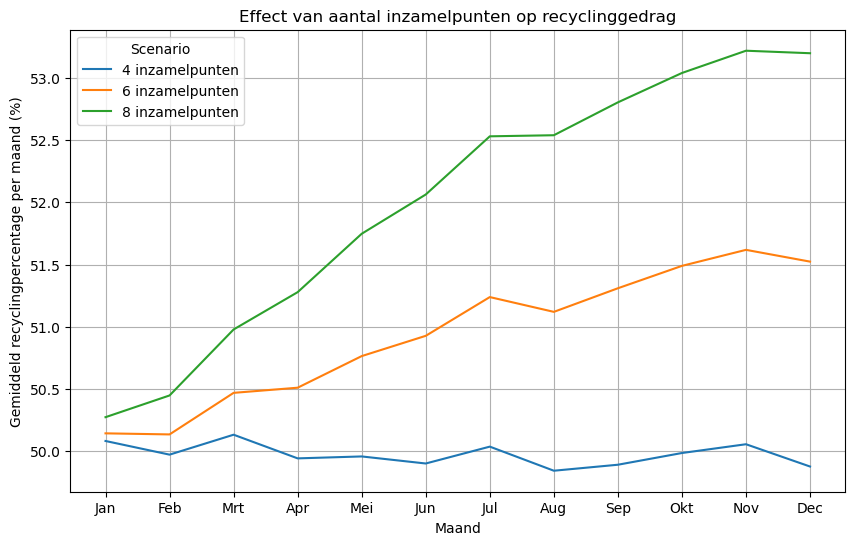

In [200]:
inzamelpunten_scenarios = [4, 6, 8]
maanden_labels = ["Jan", "Feb", "Mrt", "Apr", "Mei", "Jun",
                  "Jul", "Aug", "Sep", "Okt", "Nov", "Dec"]

plt.figure(figsize=(10, 6))

for aantal in inzamelpunten_scenarios:
    resultaten = run_multiple_simulations_for_bins(
        aantal_inzamelpunten=aantal,
        vaste_inzamelpunten=vaste_inzamelpunten,
        n_runs=5,
        maanden=12,
        grid_size=100,
        beloning=0
    )

    gemiddelde = resultaten.groupby("Maand")["RecyclingPercentageDezeMaand"].mean()

    plt.plot(
        gemiddelde.index,
        gemiddelde.values * 100,
        label=f"{aantal} inzamelpunten"
    )

plt.xlabel("Maand")
plt.ylabel("Gemiddeld recyclingpercentage per maand (%)")
plt.title("Effect van aantal inzamelpunten op recyclinggedrag")
plt.xticks(range(1, 13), maanden_labels)
plt.legend(title="Scenario")
plt.grid(True)
plt.show()